# 03 - Ein Merkmal: Power Law und lineare Regression

Wir vergleichen drei bewusst einfache Kalibrierungen auf exakt demselben
einzelnen Rohmesspunkt:

1. lineare Regression auf dem gespeicherten Sensorwert,
2. lineare Regression auf log1p des Sensorwerts,
3. empirisches Power Law C = A mal (x / s) hoch n.

Alle Modellparameter werden ausschließlich mit Train bestimmt. Der
Messpunkt wird anhand des Power-Law-RMSE auf Validation gewählt. Test und
test_extra bleiben bis zur abschließenden Auswertung unberührt.

## Software, Modelle und Eingabeparameter

Der zentrale Eingabeparameter ist GAS. Alle 48 zulässigen Temperaturgrenzpunkte
werden geprüft; ausgewählt wird ausschließlich anhand des Validation-RMSE des
Power Laws.

**Drei Modelle**

- Lineare Regression: C = a mal x + b.
- Linear nach log1p: C = a mal log(1 + x) + b.
- Power Law: C = A mal (x / s) hoch n. Die Skala s ist der Trainingsmedian und
  verbessert die numerische Kondition.

NumPy berechnet die linearen Parameter mit numpy.linalg.lstsq. Das Power Law
wird durch Logarithmieren ebenfalls als lineares Problem gelöst. Dafür müssen
Sensorwert und Ziel positiv sein. Für ein echtes nichtlineares Fitproblem könnte
man scipy.optimize.curve_fit oder scipy.optimize.least_squares verwenden; diese
Funktionen erlauben Startwerte, Parametergrenzen und robuste Verlustfunktionen.

**Was kann verändert werden?**

- GAS wählt das Zielgas.
- Die Liste der zulässigen Punkte kommt aus temperature_boundary_points.
- Als Auswahlmetrik könnte RMSE durch MAE ersetzt werden; dies ändert jedoch die
  Bedeutung der Optimierung.
- Negative Vorhersagen werden bewusst nicht abgeschnitten, damit Modellfehler
  sichtbar bleiben.

Test und test_extra dienen erst nach Punktwahl und Fit zur Bewertung.

In [ ]:
GAS = "hydrogen"

In [2]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

HERE = Path.cwd()
if not (HERE / "dataset_pipeline.py").exists():
    HERE = HERE / "Evaluation Seminar" / "Neuaufbau"
sys.path.insert(0, str(HERE.resolve()))
from dataset_pipeline import *

if GAS not in GAS_TARGETS:
    raise ValueError(f"Unbekanntes Gas: {GAS}")
plt.style.use("seaborn-v0_8-whitegrid")
splits = prepare_splits("stored")

## 1. Drei Einpunktmodelle

In [3]:
def fit_affine(z, y):
    design = np.column_stack([z, np.ones(len(z))])
    slope, intercept = np.linalg.lstsq(design, y, rcond=None)[0]
    return float(slope), float(intercept)


def make_linear_raw(x_train, y_train):
    slope, intercept = fit_affine(x_train, y_train)
    return {
        "name": "Linear: gespeicherter Wert",
        "predict": lambda x: slope * np.asarray(x) + intercept,
        "parameters": {"slope": slope, "intercept": intercept},
    }


def make_linear_log1p(x_train, y_train):
    slope, intercept = fit_affine(np.log1p(x_train), y_train)
    return {
        "name": "Linear: log1p(x)",
        "predict": lambda x: slope * np.log1p(np.asarray(x)) + intercept,
        "parameters": {"slope": slope, "intercept": intercept},
    }


def make_power_law(x_train, y_train):
    if np.any(x_train <= 0) or np.any(y_train <= 0):
        raise ValueError("Power Law benötigt positive x- und Zielwerte")
    scale = float(np.median(x_train))
    exponent, log_amplitude = fit_affine(
        np.log(x_train / scale), np.log(y_train)
    )
    amplitude = float(np.exp(log_amplitude))

    def predict(x):
        log_prediction = (
            log_amplitude
            + exponent * np.log(np.asarray(x) / scale)
        )
        return np.exp(np.clip(log_prediction, -50, 50))

    return {
        "name": "Power Law",
        "predict": predict,
        "parameters": {
            "A": amplitude, "n": exponent, "scale": scale,
        },
    }


def metrics(y_true, y_pred):
    residual = np.asarray(y_true) - np.asarray(y_pred)
    mse = float(np.mean(residual ** 2))
    denominator = float(np.sum((y_true - np.mean(y_true)) ** 2))
    return {
        "R2": 1.0 - float(np.sum(residual ** 2)) / denominator,
        "MSE": mse,
        "RMSE": mse ** 0.5,
        "MAE": float(np.mean(np.abs(residual))),
    }

Die Skalierung s ist der Median des Trainingsmerkmals. Sie verbessert die
numerische Stabilität, ohne zusätzliche Information einzuführen. Das Power
Law ist hier ein empirisches Vorhersagemodell, da der Zenodo-Datensatz
keinen separaten Referenzwiderstand R0 bereitstellt.

## 2. Einen guten Power-Law-Punkt nur mit Train und Validation wählen

In [4]:
candidates = temperature_boundary_points()
y_train = splits["train"]["targets"][GAS].astype(float)
y_val = splits["val"]["targets"][GAS].astype(float)
candidate_results = []

for point in candidates:
    x_train = splits["train"]["X"][:, 0, point.index].astype(float)
    x_val = splits["val"]["X"][:, 0, point.index].astype(float)
    model = make_power_law(x_train, y_train)
    val_prediction = model["predict"](x_val)
    candidate_results.append({
        "point": point,
        "model": model,
        "val_metrics": metrics(y_val, val_prediction),
    })

candidate_results.sort(
    key=lambda item: item["val_metrics"]["RMSE"]
)
selected_point = candidate_results[0]["point"]
print("Gewählter Punkt:", selected_point)
print("Die fünf besten Power-Law-Punkte auf Validation:")
for item in candidate_results[:5]:
    m = item["val_metrics"]
    print(
        f"{item['point'].point_id:36s} "
        f"R2={m['R2']:+.4f}, RMSE={m['RMSE']:.4f}, "
        f"MAE={m['MAE']:.4f}"
    )

Gewählter Punkt: BoundaryPoint(index=409, temperature_c=400, phase='high', cycle_step=3, edge='end')
Die fünf besten Power-Law-Punkte auf Validation:
t400_high_step03_end_i0409           R2=+0.2535, RMSE=33.5524, MAE=25.7256
t400_high_step05_end_i0649           R2=+0.2504, RMSE=33.6220, MAE=25.8002
t400_high_step01_end_i0169           R2=+0.2461, RMSE=33.7194, MAE=25.8669
t400_high_step04_end_i0529           R2=+0.2460, RMSE=33.7219, MAE=25.8817
t400_high_step02_end_i0289           R2=+0.2444, RMSE=33.7576, MAE=25.9009


## 3. Alle drei Modelle auf demselben Punkt trainieren

In [5]:
point_index = selected_point.index
x_train = splits["train"]["X"][:, 0, point_index].astype(float)
y_train = splits["train"]["targets"][GAS].astype(float)

models = [
    make_linear_raw(x_train, y_train),
    make_linear_log1p(x_train, y_train),
    make_power_law(x_train, y_train),
]
for model in models:
    print(model["name"], model["parameters"])

Linear: gespeicherter Wert {'slope': -0.056449407689715396, 'intercept': 1846.0960414607348}
Linear: log1p(x) {'slope': -1797.0527776149747, 'intercept': 18681.330396669102}
Power Law {'A': 44.39700647605917, 'n': -37.07214209259835, 'scale': 31597.5}


## 4. R², MSE, RMSE und MAE auf allen vier Splits

In [6]:
results = {}
predictions = {}
for model in models:
    results[model["name"]] = {}
    predictions[model["name"]] = {}
    for split in SPLIT_NAMES:
        x = splits[split]["X"][:, 0, point_index].astype(float)
        y = splits[split]["targets"][GAS].astype(float)
        prediction = model["predict"](x)
        predictions[model["name"]][split] = prediction
        results[model["name"]][split] = metrics(y, prediction)

print("Modell                     Split             R2"
      "           MSE          RMSE           MAE")
for model in models:
    name = model["name"]
    for split in SPLIT_NAMES:
        m = results[name][split]
        print(
            f"{name:27s} {split:10s} {m['R2']:11.4f} "
            f"{m['MSE']:13.4f} {m['RMSE']:13.4f} "
            f"{m['MAE']:13.4f}"
        )
    print()

Modell                     Split             R2           MSE          RMSE           MAE
Linear: gespeicherter Wert  train           0.2704     1389.7394       37.2792       31.0805
Linear: gespeicherter Wert  val             0.2884     1073.1300       32.7587       26.9292
Linear: gespeicherter Wert  test            0.2352     1081.3116       32.8833       25.9234
Linear: gespeicherter Wert  test_extra     -0.7654    36573.9949      191.2433      155.5545

Linear: log1p(x)            train           0.2716     1387.6417       37.2511       31.0381
Linear: log1p(x)            val             0.2901     1070.5344       32.7190       26.8703
Linear: log1p(x)            test            0.2348     1081.8993       32.8922       25.9022
Linear: log1p(x)            test_extra     -0.7453    36157.1760      190.1504      154.6227

Power Law                   train           0.1823     1557.6534       39.4671       30.3763
Power Law                   val             0.2535     1125.7645       

## 5. Direkter Metrikvergleich

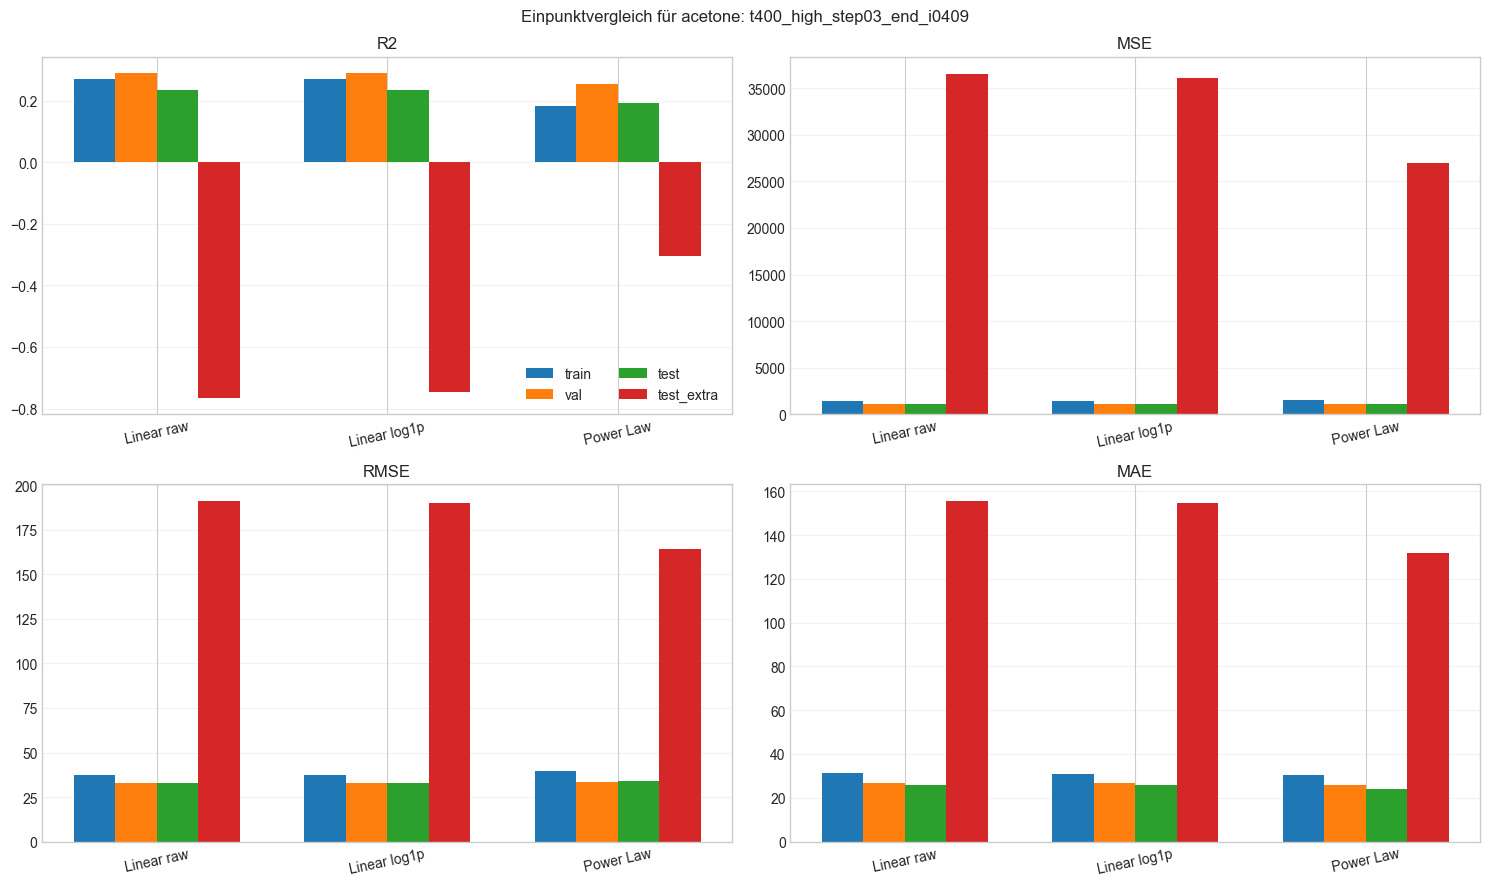

In [7]:
metric_names = ("R2", "MSE", "RMSE", "MAE")
split_colors = {
    "train": "tab:blue", "val": "tab:orange",
    "test": "tab:green", "test_extra": "tab:red",
}
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
positions = np.arange(len(models))
width = 0.18
for ax, metric_name in zip(axes.ravel(), metric_names):
    for offset, split in enumerate(SPLIT_NAMES):
        values = [
            results[model["name"]][split][metric_name]
            for model in models
        ]
        ax.bar(
            positions + (offset - 1.5) * width, values,
            width=width, label=split, color=split_colors[split]
        )
    ax.set_title(metric_name)
    ax.set_xticks(positions)
    ax.set_xticklabels(
        ["Linear raw", "Linear log1p", "Power Law"],
        rotation=12
    )
    ax.grid(axis="y", alpha=0.25)
axes[0, 0].legend(ncol=2)
fig.suptitle(
    f"Einpunktvergleich für {GAS}: {selected_point.point_id}"
)
plt.tight_layout()

## 6. Trainingsdaten und gelernte Kurven

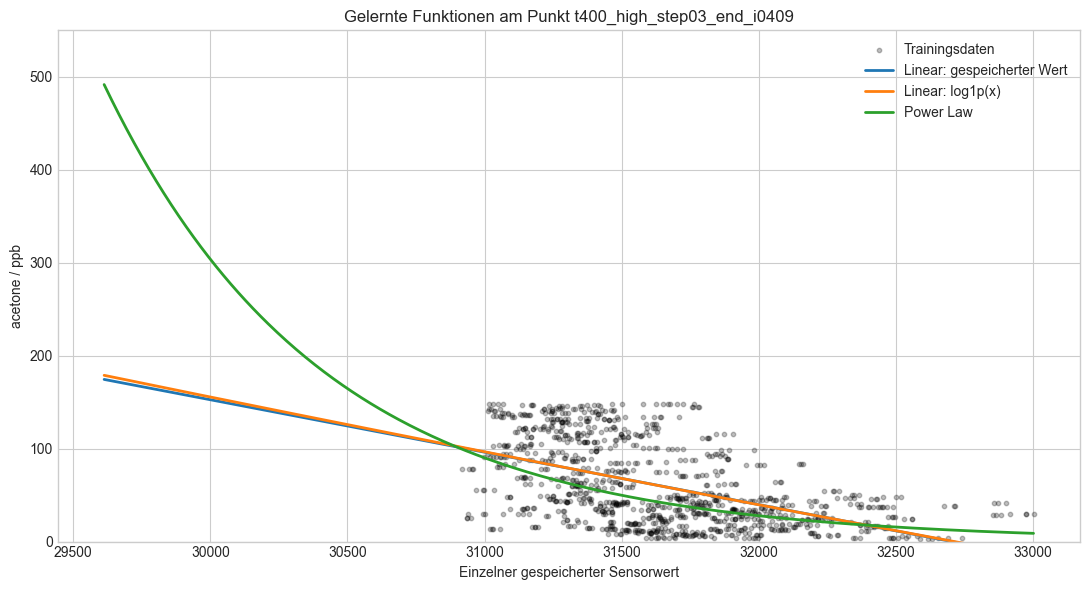

In [8]:
all_x = np.concatenate([
    splits[split]["X"][:, 0, point_index]
    for split in SPLIT_NAMES
])
grid = np.linspace(all_x.min(), all_x.max(), 500)
fig, ax = plt.subplots(figsize=(11, 6))
ax.scatter(
    x_train, y_train, s=10, alpha=0.25,
    color="black", label="Trainingsdaten"
)
for model in models:
    ax.plot(
        grid, model["predict"](grid), linewidth=2,
        label=model["name"]
    )
target_max = max(
    float(splits[split]["targets"][GAS].max())
    for split in SPLIT_NAMES
)
ax.set_ylim(bottom=0, top=target_max * 1.10)
ax.set(
    xlabel="Einzelner gespeicherter Sensorwert",
    ylabel=f"{GAS} / ppb",
    title=f"Gelernte Funktionen am Punkt {selected_point.point_id}"
)
ax.legend()
plt.tight_layout()

## 7. Paritätsplots für alle Modelle und Splits

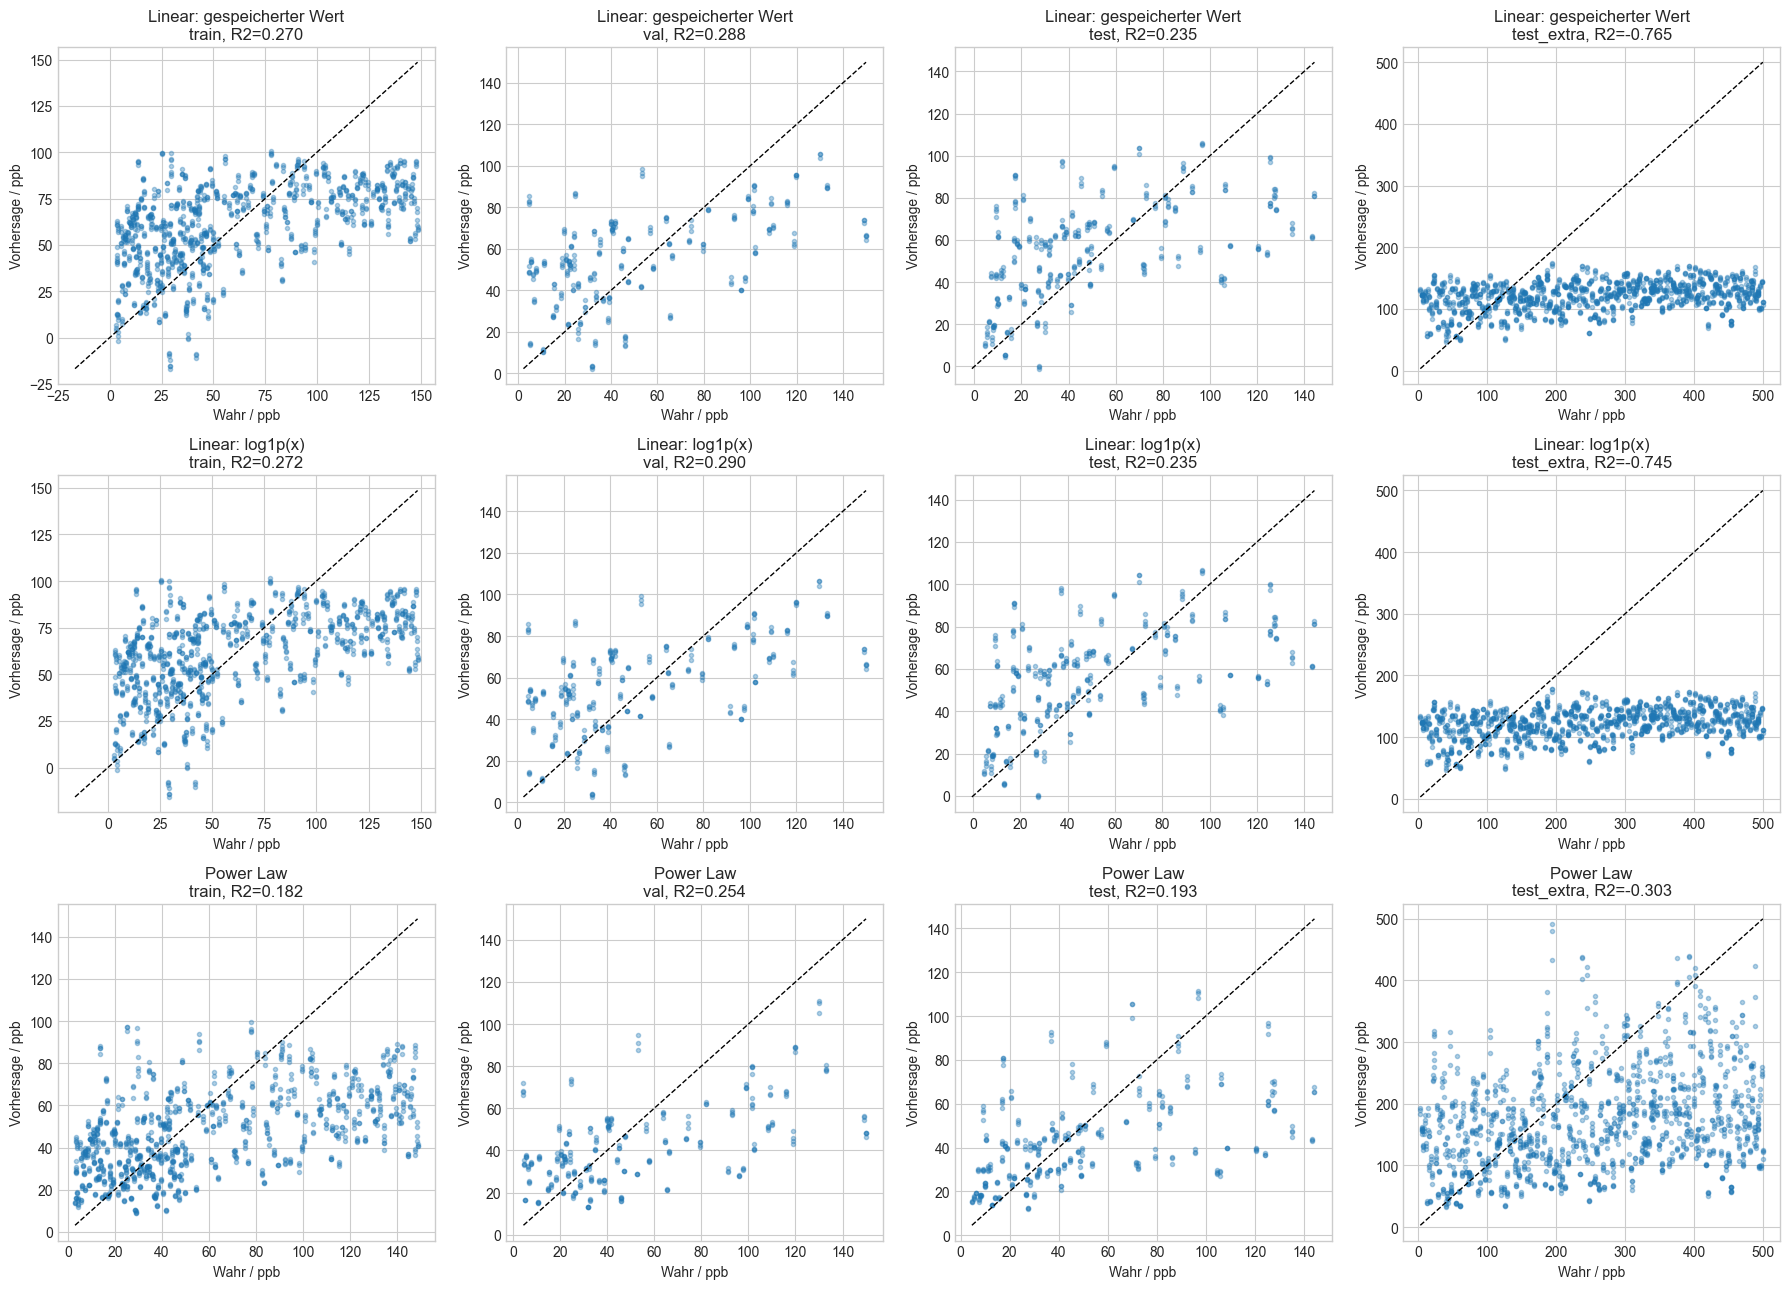

In [9]:
fig, axes = plt.subplots(
    len(models), len(SPLIT_NAMES), figsize=(18, 13)
)
for row, model in enumerate(models):
    name = model["name"]
    for column, split in enumerate(SPLIT_NAMES):
        ax = axes[row, column]
        y = splits[split]["targets"][GAS].astype(float)
        pred = predictions[name][split]
        ax.scatter(y, pred, s=9, alpha=0.35)
        finite_pred = pred[np.isfinite(pred)]
        low = min(float(y.min()), float(finite_pred.min()))
        high = max(float(y.max()), float(finite_pred.max()))
        ax.plot([low, high], [low, high], "k--", linewidth=1)
        ax.set_title(
            f"{name}\n{split}, "
            f"R2={results[name][split]['R2']:.3f}"
        )
        ax.set_xlabel("Wahr / ppb")
        ax.set_ylabel("Vorhersage / ppb")
plt.tight_layout()

Interpretation: Der reguläre Test misst Interpolation auf neuen UGMs
innerhalb der ersten beiden Segmente. test_extra prüft echte
Extrapolation in das letzte Segment. Ein gutes Interpolationsergebnis
garantiert daher ausdrücklich kein gutes Extra-Test-Ergebnis.